In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text
import os

# Configuring visual defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Move to project root 
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

load_dotenv() 

## Database Connection
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine =create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    result = conn.execute(text("select count(*) from fraud_dw.fact_transactions"))
    count = result.scalar()
    print(f"Connected to database. Fact_transactions has {count:,} rows.")


Working directory: d:\Innomatics\Git_Uploads\Credit-card-risk-analytics
Connected to database. Fact_transactions has 590,540 rows.


### Phase 01 -- Fraud landscape

**Business Questions** -- How big is the fraud pronlem and where is it concentrated ?

This notebook establishes the baseline fraud metrics -- overall rates, product breakdowns, card-network and card-type distributions, and amoub=nt distributions. These numbers are the foundation that every subsequent phase builds on.

**Source Data --** 590,540 transacrions, Dec 2017 - Jun 2018, from the IEEE - CIS fraud Detection dataset

**Techniques Showcased --** 'filter' clause, 'Percentile_cont', 'grouping sets'.
 

Each query from sql will be imported as a dataframe and data visualization will be done the get the insights from the query.

In [3]:
# -- 01. Overall fraud_rate by count and by transactional amount

query_1 ="""
select
		count(*) 												as tot_transactions,
		count(*) filter (where is_fraud is true)				as fraud_transactions,
		round(100 * count(*) filter (where is_fraud)
						/count(*),2)							as fraud_rate_count_pct,

		round(sum(transaction_amt),2)							as total_amount,
		round(sum(transaction_amt) filter(where is_fraud),2)	as fraud_amount,
		round(100 * sum(transaction_amt) filter(where is_fraud)
				/ sum(transaction_amt),2)						as fraud_rate_amount_pct
from fraud_dw.fact_transactions;
"""

df1 = pd.read_sql(query_1,engine)
df1

,tot_transactions,fraud_transactions,fraud_rate_count_pct,total_amount,fraud_amount,fraud_rate_amount_pct
0,590540,20663,3.0,79738980.37,3083847.67,3.87


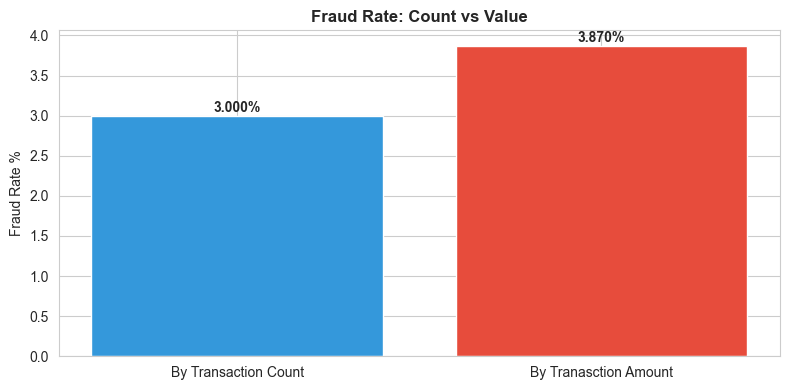

In [5]:
## Query 1 vis

fig, ax = plt.subplots(figsize =(8,4))

categories = ["By Transaction Count", "By Tranasction Amount"]
rates = [df1["fraud_rate_count_pct"].iloc[0],df1["fraud_rate_amount_pct"].iloc[0]]

bars = ax.bar(categories,rates,color = ['#3498db', '#e74c3c'])
ax.set_ylabel("Fraud Rate %")
ax.set_title('Fraud Rate: Count vs Value', fontsize=12, fontweight='bold')

for bar, rate in zip(bars,rates):
    ax.text(bar.get_x()+ bar.get_width()/2, bar.get_height() + 0.05,
            f'{rate:.3f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("visuals/phase1_q1_fraud_rate_overview.png", bbox_inches='tight')
plt.show()

### Insight 1: Fraud is rare but value-heavy

- **3% of all transactions are fraudulent** — about 1 in every 29 transactions.
- **Fraud accounts for 3.87% of total transaction amount** — replace with your actual result.
- If the value rate exceeds the count rate, fraudsters target higher-value transactions. 
  This is what we'd expect: organized fraud rings prefer high-ticket targets.

**Implication:** A fraud detection system needs to optimize for value caught, not 
just transaction count. Catching 100 small-dollar attacks is less valuable than 
catching 10 large-dollar ones.

In [2]:
# -- fraud_rate by product category

query_2 ="""
select 
		p.product_category,
		count(*) 										as txn_count,
		count(*) filter (where f.is_fraud)				as fraud_count,
		round(100 * count(*) filter (where f.is_fraud)	
						/count(*),2)					as fraud_rate_pct,
						
		round(sum(f.transaction_amt),2)							as total_amount,
		round(sum(f.transaction_amt) filter(where is_fraud),2)	as fraud_amount
from fraud_dw.fact_transactions f
left join fraud_dw.dim_product p
on f.product_id = p.product_id
group by p.product_category
order by fraud_rate_pct desc;
"""
df2 = pd.read_sql(query_2,engine)
df2



,product_category,txn_count,fraud_count,fraud_rate_pct,total_amount,fraud_amount
0,Card-Not-Present,68519,8008,11.0,2937602.40,391424.21
1,Subscription,11628,686,5.0,700813.60,43416.00
2,Hotel/Travel,33024,1574,4.0,2416368.00,246632.00
3,Retail,37699,1426,3.0,6344975.00,348050.00
4,Web Purchase,439670,8969,2.0,67339221.37,2054325.46


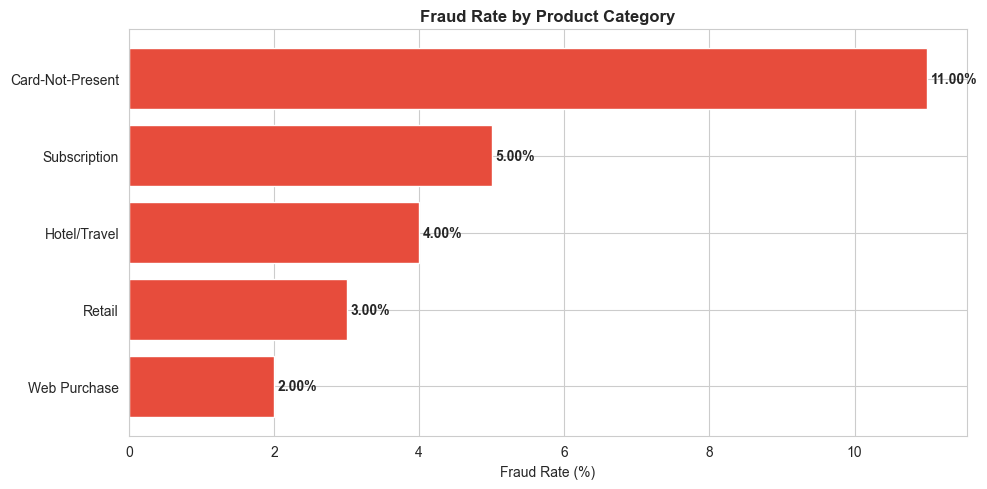

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(df2['product_category'], df2['fraud_rate_pct'], color='#e74c3c')
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Product Category', fontsize=12, fontweight='bold')
ax.invert_yaxis()  # highest at top

# Add value labels
for bar, rate in zip(bars, df2['fraud_rate_pct']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{rate:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/phase1_q2_fraud_by_product.png', bbox_inches='tight')
plt.show()

### Insight 2: Card-Not-Present and Web Purchase dominate fraud

- The product category with the highest fraud rate is **Card Not Present**.
- This aligns with industry knowledge: physical-card-required transactions (Retail, Hotel/Travel) 
  have lower fraud because the attacker needs the actual card.
- **Card-Not-Present (CNP)** transactions are inherently riskier — fraudsters only need 
  the card number, not the physical card.

**Implication:** Risk teams should apply tighter rules to CNP and Web Purchase categories. 
Step-up authentication (3DS, OTP) is justified for these channels.

In [3]:
## --  03.fraud_rate by card_network

query_3 = """
select 
		c.card_network,		
		count(*) 										as txn_count,
		count(*) filter (where f.is_fraud)				as fraud_count,
		round(100 * count(*) filter (where f.is_fraud)	
						/count(*),2)					as fraud_rate_pct,
		round(avg(transaction_amt),2)					as avg_txn_amt,
		round(avg(transaction_amt) filter 
				(where is_fraud),2)						as avg_fraud_amt
from fraud_dw.fact_transactions f
join fraud_dw.dim_card c using (card_id)
group by c.card_network
order by txn_count desc;"""

df3 = pd.read_sql(query_3,engine)
df3

,card_network,txn_count,fraud_count,fraud_rate_pct,avg_txn_amt,avg_fraud_amt
0,Visa,384767,13373,3.0,133.16,149.38
1,Mastercard,189217,6496,3.0,132.39,131.73
2,American Express,8328,239,2.0,173.06,179.07
3,Discover,6651,514,7.0,265.75,354.09
4,Unknown,1577,41,2.0,154.69,136.62


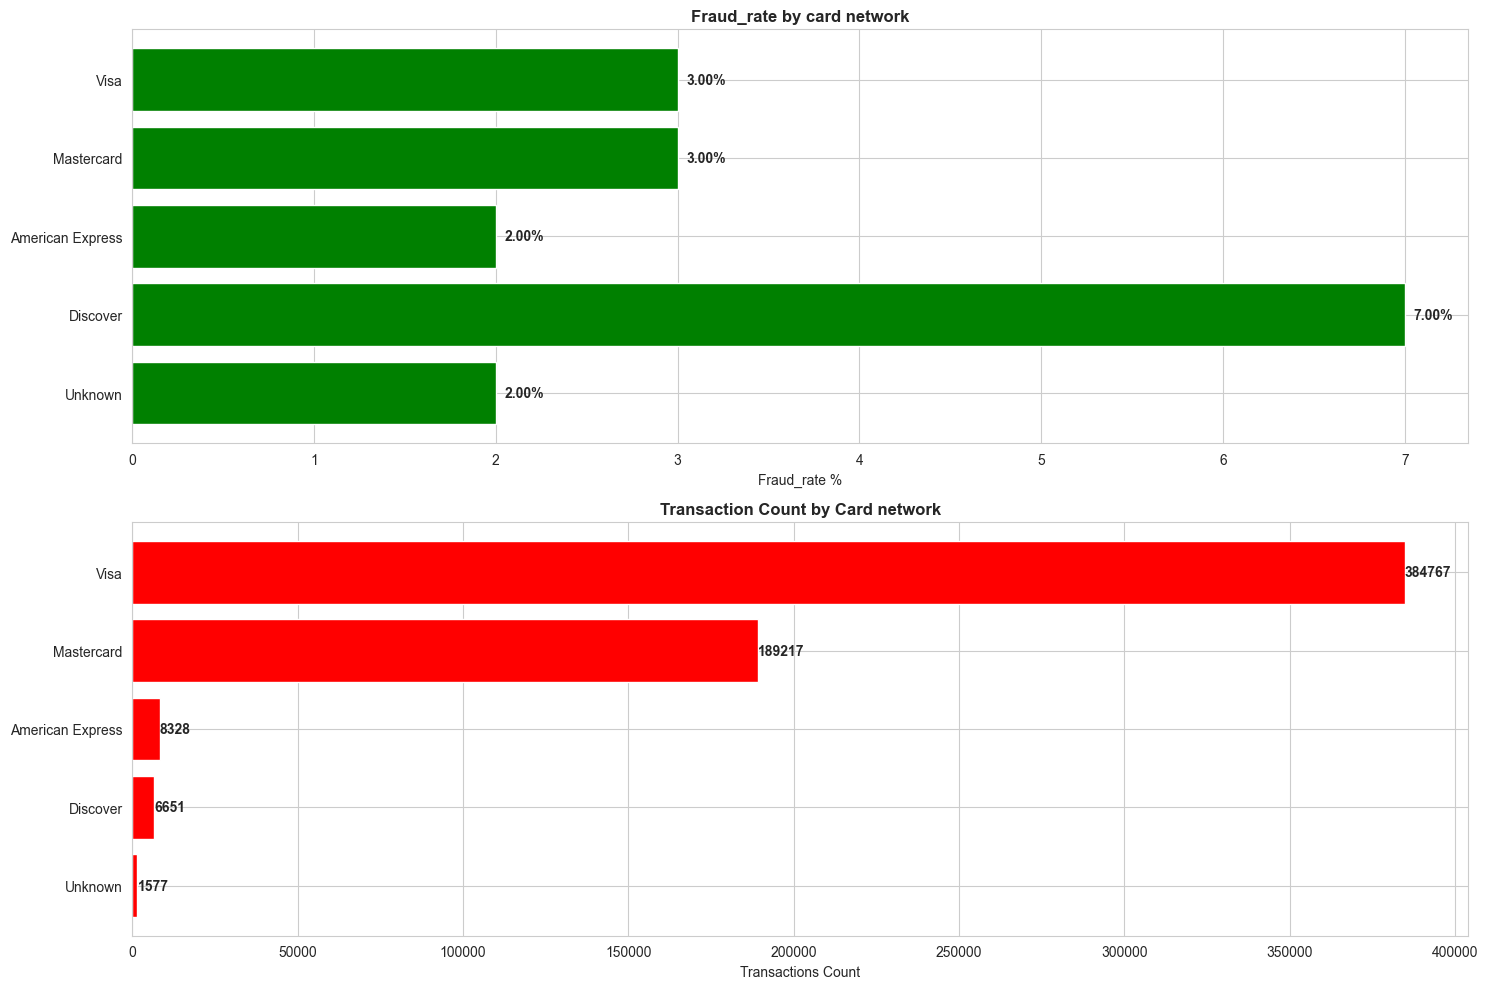

In [31]:
fig, ax = plt.subplots(nrows=2,ncols=1,figsize = (15,10))
bar1 = ax[0].barh(df3["card_network"],df3["fraud_rate_pct"],color = "green")
ax[0].set_xlabel("Fraud_rate %")
ax[0].set_title("Fraud_rate by card network",fontsize=12, fontweight='bold')
ax[0].invert_yaxis()

for bar, rate in zip(bar1, df3['fraud_rate_pct']):
    ax[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{rate:.2f}%', va='center', fontweight='bold')

bar2 = ax[1].barh(df3["card_network"],df3["txn_count"],color = "red")
ax[1].set_xlabel("Transactions Count")
ax[1].set_title("Transaction Count by Card network",fontsize=12, fontweight='bold')
ax[1].invert_yaxis()

for bar, rate in zip(bar2, df3['txn_count']):
    ax[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{rate:.0f}', va='center', fontweight='bold')
    
plt.tight_layout()
plt.savefig('visuals/phase1_q3_fraud_by_card_network.png', bbox_inches='tight')
plt.show()


## Insight 03





--

In [26]:
## -- 04.fraud rate by card type

query_4 = """
select 
		c.card_type,		
		count(*) 										as txn_count,
		count(*) filter (where f.is_fraud)				as fraud_count,
		round(100 * count(*) filter (where f.is_fraud)	
						/count(*),2)					as fraud_rate_pct,
		round(avg(transaction_amt),2)					as avg_txn_amt,
		round(avg(transaction_amt) filter 
				(where is_fraud),2)						as avg_fraud_amt
from fraud_dw.fact_transactions f
join fraud_dw.dim_card c using (card_id)
group by c.card_type
order by txn_count desc;
"""

df4 = pd.read_sql(query_4,engine)
df4

,card_type,txn_count,fraud_count,fraud_rate_pct,avg_txn_amt,avg_fraud_amt
0,Debit,439938,10674,2.0,116.33,133.22
1,Credit,148986,9950,6.0,190.03,166.51
2,Unknown,1571,39,2.0,154.85,129.52
3,Debit Or Credit,30,0,0.0,104.07,NaN
4,Charge Card,15,0,0.0,59.53,NaN


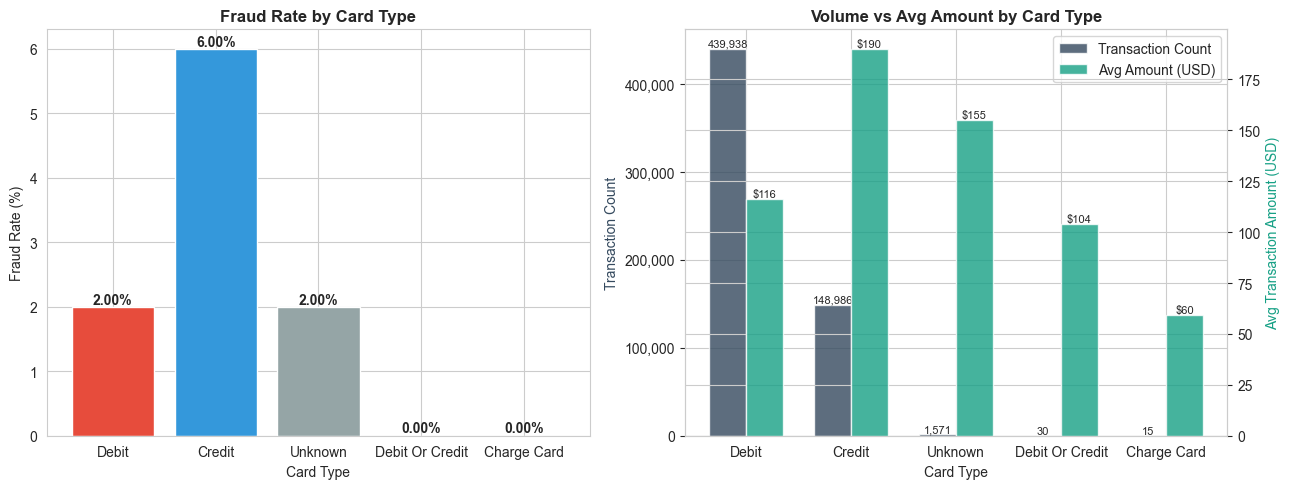

In [38]:
# Q4 chart — Credit vs Debit fraud comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))


bars1 = axes[0].bar(df4['card_type'], df4['fraud_rate_pct'], 
                    color=['#e74c3c', '#3498db', '#95a5a6', '#f39c12'][:len(df4)])
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Card Type')
axes[0].set_title('Fraud Rate by Card Type', fontsize=12, fontweight='bold')


for bar, rate in zip(bars1, df4['fraud_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{rate:.2f}%', ha='center', fontweight='bold')


ax2 = axes[1]
ax2_twin = ax2.twinx()

x_pos = range(len(df4))
width = 0.35

bars2 = ax2.bar([x - width/2 for x in x_pos], df4['txn_count'], 
                width=width, color='#34495e', label='Transaction Count', alpha=0.8)
bars3 = ax2_twin.bar([x + width/2 for x in x_pos], df4['avg_txn_amt'], 
                     width=width, color='#16a085', label='Avg Amount (USD)', alpha=0.8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(df4['card_type'])
ax2.set_xlabel('Card Type')
ax2.set_ylabel('Transaction Count', color='#34495e')
ax2_twin.set_ylabel('Avg Transaction Amount (USD)', color='#16a085')
ax2.set_title('Volume vs Avg Amount by Card Type', fontsize=12, fontweight='bold')


ax2.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'))


lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')


for bar, val in zip(bars2, df4['txn_count']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{int(val):,}', ha='center', va='bottom', fontsize=8)


for bar, val in zip(bars3, df4['avg_txn_amt']):
    ax2_twin.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                  f'${val:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('visuals/phase1_q4_credit_vs_debit.png', bbox_inches='tight')
plt.show()

## Insight_04

In [39]:
## -- 05.Statistical distribution between Legit nd fraud transaction
## -- Finding Quantiles,min, max,mean, modian

query_5="""
select
		is_fraud,
		count(*) 										as txn_count,
		round(min(transaction_amt),2)					as min_amt,
		round(percentile_cont(0.25) within group
				(order by transaction_amt)::numeric,2)	as p25,
		round(percentile_cont(0.50) within group
				(order by transaction_amt)::numeric,2)	as median,
		round(avg(transaction_amt),2)					as mean,
		round(percentile_cont(0.75) within group
				(order by transaction_amt)::numeric,2)	as p75,
		round(percentile_cont(0.95) within group
				(order by transaction_amt)::numeric,2)	as p95,
		round(max(transaction_amt),2)					as max_amt
from 	fraud_dw.fact_transactions
group by is_fraud
order by is_fraud;"""

df5=pd.read_sql(query_5,engine)
df5

,is_fraud,txn_count,min_amt,p25,median,mean,p75,p95,max_amt
0,False,569877,0.25,43.97,68.5,134.51,120.0,435.0,31937.39
1,True,20663,0.29,35.04,75.0,149.24,161.0,500.0,5191.00


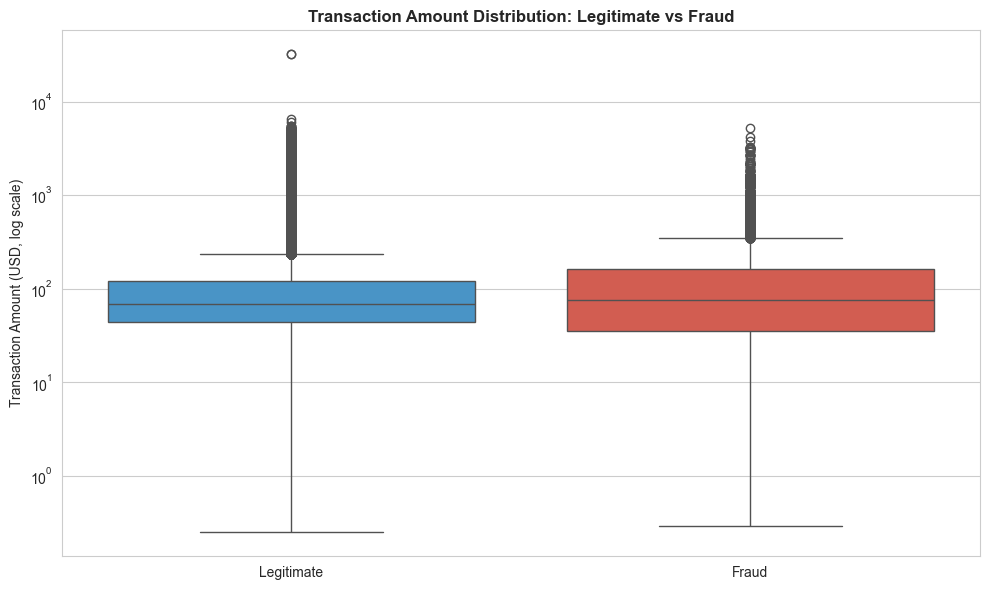

In [ ]:
# Q5 chart — log scale for amount distribution
fig, ax = plt.subplots(figsize=(10, 6))

# taking the raw data
raw_q = """
SELECT is_fraud, transaction_amt 
FROM fraud_dw.fact_transactions
WHERE transaction_amt > 0
"""
df_raw = pd.read_sql(raw_q, engine)
df_raw['label'] = df_raw['is_fraud'].map({False: 'Legitimate', True: 'Fraud'})

sns.boxplot(data=df_raw, x='label', y='transaction_amt', 
            ax=ax, hue='label', palette=['#3498db', '#e74c3c'], legend=False)
ax.set_yscale('log')  
ax.set_ylabel('Transaction Amount (USD, log scale)')
ax.set_xlabel('')
ax.set_title('Transaction Amount Distribution: Legitimate vs Fraud', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/phase1_q5_amount_distribution.png', bbox_inches='tight')
plt.show()

In [43]:
## -- 06. checking multiple aggregation levels of feaud_rate
query_6="""
select
		coalesce(p.product_category,'All Products')					as product_category,
		coalesce(c.card_type,'All types')							as card_type,
		count(*)													as txn_count,
		count(*) filter (where is_fraud)							as fraud_count,
		round(100 * count(*) filter (where is_fraud)
					/ count(*),2)									as fraud_pct
from fraud_dw.fact_transactions f
join fraud_dw.dim_product p using (product_id)
join fraud_dw.dim_card c using (card_id)
group by grouping sets (
    (p.product_category, c.card_type),     -- detail level
    (p.product_category),                  -- by product only
    (c.card_type),                         -- by card type only
    ()                                     -- grand total
)

order by CASE WHEN p.product_category IS NULL THEN 2 ELSE 1 END,
					p.product_category,
					CASE WHEN c.card_type IS NULL THEN 2 ELSE 1 END,
					c.card_type;
     """
     
df6 = pd.read_sql(query_6,engine)
df6.sample(10)

,product_category,card_type,txn_count,fraud_count,fraud_pct
17,Subscription,All types,11628,686,5.0
12,Retail,Unknown,5,0,0.0
8,Hotel/Travel,All types,33024,1574,4.0
28,All Products,All types,590540,20663,3.0
14,Subscription,Credit,6527,371,5.0
26,All Products,Debit Or Credit,30,0,0.0
18,Web Purchase,Credit,70753,3006,4.0
11,Retail,Debit,11192,394,3.0
13,Retail,All types,37699,1426,3.0
19,Web Purchase,Debit,367516,5942,1.0


In [46]:
df6["product_category"].unique()

<ArrowStringArray>
['Card-Not-Present',     'Hotel/Travel',           'Retail',
     'Subscription',     'Web Purchase',     'All Products']
Length: 6, dtype: str

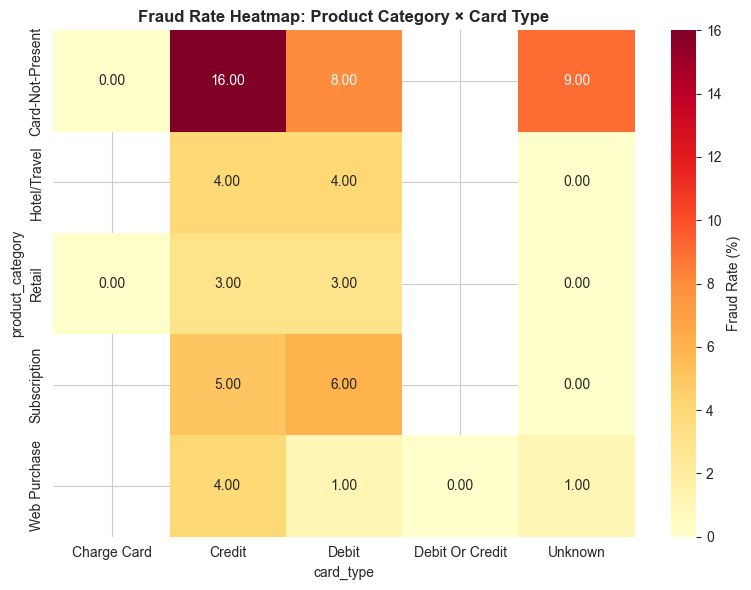

In [47]:
# Filter to detail rows only (exclude subtotals)
detail = df6[(df6['product_category'] != 'All Products') & 
             (df6['card_type'] != 'All types')]

pivot = detail.pivot(index='product_category', 
                     columns='card_type', 
                     values='fraud_pct')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Fraud Rate (%)'}, ax=ax)
ax.set_title('Fraud Rate Heatmap: Product Category × Card Type',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/phase1_q6_heatmap.png', bbox_inches='tight')
plt.show()